In [1]:
import numpy as np
import pandas as pd

import healpy as hp
import skyproj

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import astropy.coordinates
from astropy import units as u
from scipy import stats

import galstreams  # contains stream data
%matplotlib inline

from roman_nearfield import (change_coord, plot_streams, plot_galaxies, select_galaxies_in_footprint,
                              read_galaxies, read_gcs, plot_gcs, DATA_DIR)

## set up Gaia background and various footprints

In [2]:
# read in healpix Gaia map
filename = DATADIR / 'gaia_stellar_density_map_G_21_gal_nside_128_v0.fits'
gaiamap = hp.read_map(filename)
#gaiamap = change_coord(gaiamap, ['G', 'C'])
gaiamap -= np.min(gaiamap)
scale = np.std(gaiamap)*0.2
print(scale)
scaled_gmap = np.asinh(gaiamap/scale)
stats.describe(scaled_gmap)

NameError: name 'DATADIR' is not defined

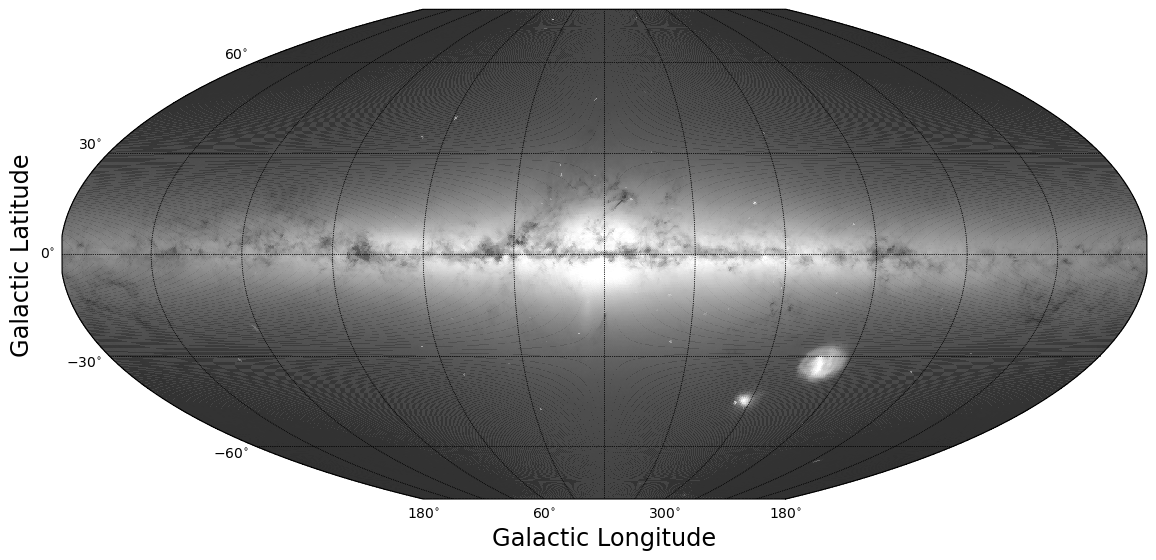

In [3]:
fig = plt.figure(1, figsize=(14, 10))
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax, extent=[-180,180, -90, 90],  galactic=True)
sp.draw_hpxmap(scaled_gmap,alpha=0.9,cmap='gray',vmin=-1.0,vmax=4.5)
plt.show()

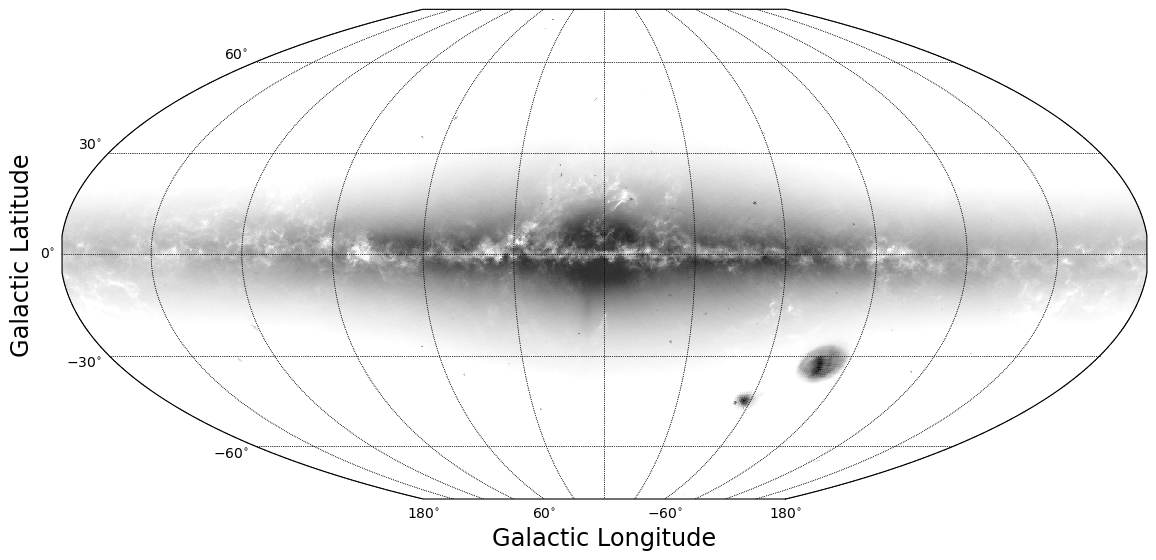

In [4]:
fig = plt.figure(1, figsize=(14, 10))
ax = fig.add_subplot(111)
sp = skyproj.sp = skyproj.McBrydeSkyproj(ax=ax, extent=[-180,180, -90, 90],  longitude_ticks='symmetric',galactic=True)
sp.draw_hpxmap(scaled_gmap,alpha=0.9,cmap='gray_r',vmin=0.5,vmax=5.0)
plt.show()

In [3]:
# Read maps with the "tiles" covered -- these are built from APT's outputs
HLWAS_wide = hp.read_map(DATA_DIR / 'HLWAS_WIDE_0328_APT994_1024.fits.gz')
HLWAS_medium = hp.read_map(DATA_DIR / 'HLWAS_MEDIUM_0328_APT994_1024.fits.gz')
GPS = hp.read_map(DATA_DIR / 'GPS_ALL_0328_1024.fits.gz')
maps = [HLWAS_wide, HLWAS_medium, GPS]

In [6]:
# Combine all maps -- HLWAS Wide = 1, HLWAS medium = 2, GPS = 3
debug = False
combined_map = np.zeros_like(HLWAS_wide)
for i, m in enumerate(maps):
    m[m==hp.UNSEEN] = 0.
    combined_map[m!=0] = (i+1)*1.0
    if debug:
        hp.mollview(combined_map, coord=['C','G'])

In [7]:
combined_map[combined_map <=0] = hp.UNSEEN # Fill back with UNSEEN
combined_map = change_coord(combined_map,['C','G'])

In [8]:
# Create a custom colorbar for the 3 maps
from matplotlib.colors import ListedColormap
import matplotlib
# Let's also design our color mapping: 1s should be plotted in blue, 2s in red, etc...
col_dict = {1: "palegreen", # "lightskyblue",
            2: "limegreen", # "dodgerblue",
            3: "firebrick"}

# We create a colormar from our list of colors
cm = ListedColormap([col_dict[x] for x in col_dict.keys()])

# Let's also define the description of each category : 1 (blue) is Sea; 2 (red) is burnt, etc... Order should be respected here ! Or using another dict maybe could help.
labels = np.array(["HLWAS WIDE", "HLWAS MEDIUM", "GPS"])
len_lab = len(labels)

In [9]:
# Add coordinates for GTBDS and HLTDS
gbtds_one = astropy.coordinates.SkyCoord('17h50m16.8700s', '-28d41m11.10s')
gbtds_two = astropy.coordinates.SkyCoord('17h49m53.4700s','-28d49m31.00s')
elais_n1 = astropy.coordinates.SkyCoord('16h10m1.0000s', '+54d30m36.00s')
euclid_s_wide = astropy.coordinates.SkyCoord('04h14m24.0000s', '-47d36m0.00s')
euclid_s_deep = astropy.coordinates.SkyCoord('03h55m36.0000s', '-49d19m12.00s')
hlwas_cosmos = astropy.coordinates.SkyCoord('10h00m24.0000s', '+02d10m55.00s')
hlwas_xmm = astropy.coordinates.SkyCoord('02h22m50.0000s', '-04d45m0.00s')

In [10]:
#read the stream catalog
mws = galstreams.MWStreams(verbose=False, implement_Off=False, print_topcat_friendly_files=False)

Initializing galstreams library from master_log... 


## all-sky figure in Galactic coordinates, with streams superimposed by distance

### version with just the footprints

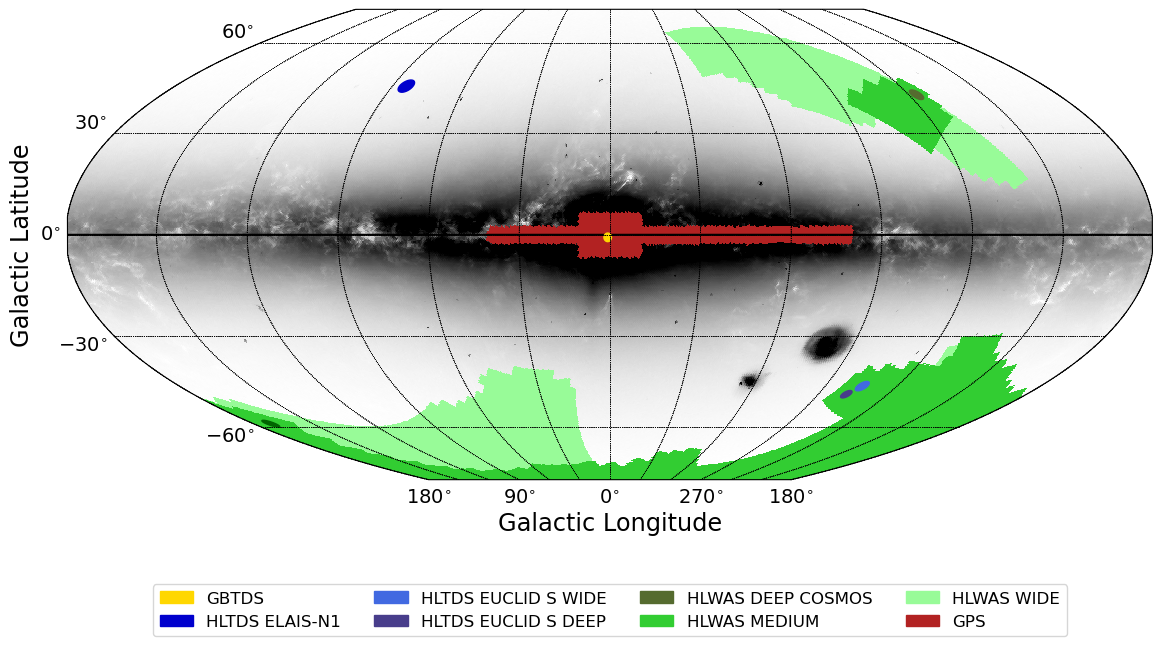

In [11]:
fig = plt.figure(1, figsize=(14, 11))
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax, extent=[-180,180, -90, 90], galactic=True, min_lon_ticklabel_delta=0.06)

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0)

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(-180,180), lat_range=(-90, 90), alpha=alph, vmin=1, vmax=3, cmap=cm)

sp.draw_milky_way(width=0,zorder=1)
patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')
patch_GPS = mpatches.Patch(color=col_dict[3], label='GPS')

# Add circles for the other surveys -- the size of the circles are kind of proportional to their footprints but it's not the actual size
#GBTDS
sp.circle(gbtds_one.galactic.l.value, gbtds_one.galactic.b.value, 2.5/2, label='GBTDS', fill=True, alpha=alph, color='gold')
#HLTDS
sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)
#HLWAS DEEP
sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)


#plot stream tracks

#cbh = plot_streams(sp, mws, dist=True)


#make legend
handles, labels = sp.ax.get_legend_handles_labels()
#handles.extend([patch_HLWAS_w, patch_HLWAS_m, patch_GPS])
shandles = handles[0:5]
shandles.extend([patch_HLWAS_m,patch_HLWAS_w])
shandles.extend([patch_GPS])
#shandles.extend(handles[5:])


box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

sp.legend(handles=shandles, loc='lower center', ncol=4, bbox_to_anchor=(0, -0.35, 1.0, 0.55), fontsize=12)

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
#plt.colorbar(cbh,label='Distance (kpc)', shrink=0.5)
#plt.savefig('../figures/ccs_footprints_streams.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_galactic.png',dpi=300,bbox_inches='tight')
plt.show()

### version with no labels

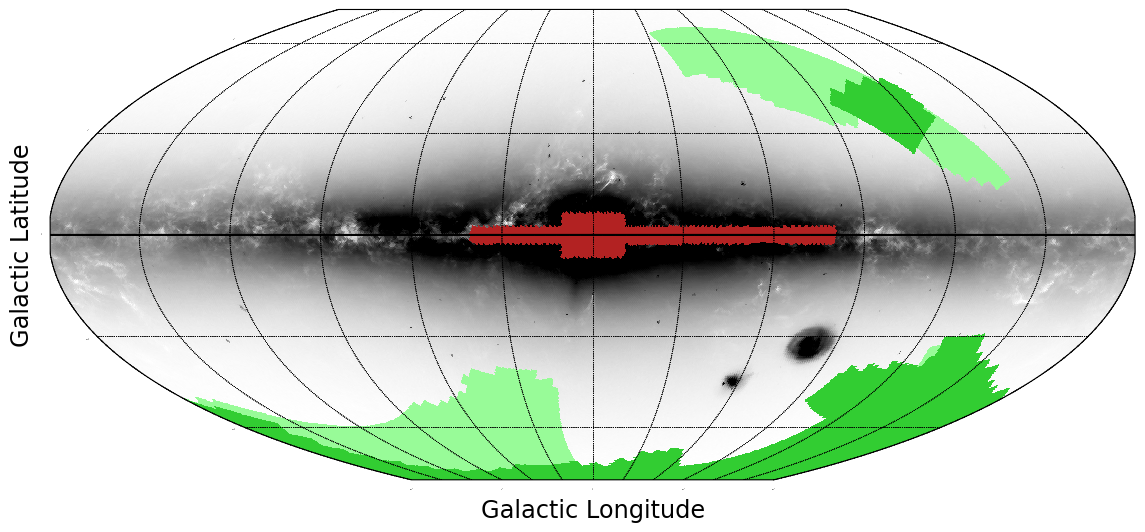

In [12]:
fig = plt.figure(1, figsize=(14, 11))
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax, extent=[-180,180, -90, 90], galactic=True, min_lon_ticklabel_delta=0.06)

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0)

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(-180,180), lat_range=(-90, 90), alpha=alph, vmin=1, vmax=3, cmap=cm)

sp.draw_milky_way(width=0,zorder=1)
patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')
# patch_GPS = mpatches.Patch(color=col_dict[3], label='GPS')

# Add circles for the other surveys -- the size of the circles are kind of proportional to their footprints but it's not the actual size
#GBTDS
# sp.circle(gbtds_one.galactic.l.value, gbtds_one.galactic.b.value, 2.5/2, label='GBTDS', fill=True, alpha=alph, color='gold')
# #HLTDS
# sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
# sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
# sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)
# #HLWAS DEEP
# sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
# sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)


#plot stream tracks

#cbh = plot_streams(sp, mws, dist=True)


#make legend
# handles, labels = sp.ax.get_legend_handles_labels()
# #handles.extend([patch_HLWAS_w, patch_HLWAS_m, patch_GPS])
# shandles = handles[0:5]
# shandles.extend([patch_HLWAS_m,patch_HLWAS_w])
# shandles.extend([patch_GPS])
# #shandles.extend(handles[5:])


# box = ax.get_position()
# ax.set_position([box.x0, box.y0 + box.height * 0.1,
#                  box.width, box.height * 0.9])

# sp.legend(handles=shandles, loc='lower center', ncol=4, bbox_to_anchor=(0, -0.35, 1.0, 0.55), fontsize=12)

sp.ax.tick_params(axis="x", labelsize=0)
sp.ax.tick_params(axis="y", labelsize=0)
#plt.colorbar(cbh,label='Distance (kpc)', shrink=0.5)
#plt.savefig('../figures/ccs_footprints_streams.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/hlwas_footprint_galactic_nolabel.png',dpi=300,bbox_inches='tight')
plt.show()

### version with streams

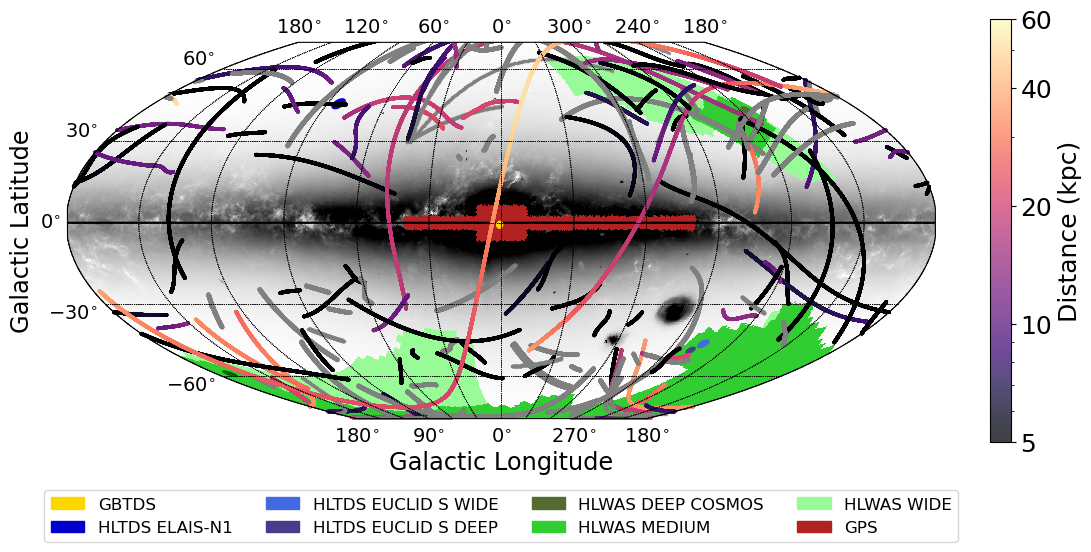

In [13]:
fig = plt.figure(1, figsize=(14, 11))
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax, extent=[-180,180, -90, 90], galactic=True, min_lon_ticklabel_delta=0.06)

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0)

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(-180,180), lat_range=(-90, 90), alpha=alph, vmin=1, vmax=3, cmap=cm)

sp.draw_milky_way(width=0,zorder=1)
patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')
patch_GPS = mpatches.Patch(color=col_dict[3], label='GPS')

# Add circles for the other surveys -- the size of the circles are kind of proportional to their footprints but it's not the actual size
#GBTDS
sp.circle(gbtds_one.galactic.l.value, gbtds_one.galactic.b.value, 2.5/2, label='GBTDS', fill=True, alpha=alph, color='gold')
#HLTDS
sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)
#HLWAS DEEP
sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)


#plot stream tracks

cbh = plot_streams(sp, mws, dist=True)


#make legend
handles, labels = sp.ax.get_legend_handles_labels()
#handles.extend([patch_HLWAS_w, patch_HLWAS_m, patch_GPS])
shandles = handles[0:5]
shandles.extend([patch_HLWAS_m,patch_HLWAS_w])
shandles.extend([patch_GPS])
#shandles.extend(handles[5:])


box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

sp.legend(handles=shandles, loc='lower center', ncol=4, bbox_to_anchor=(0, -0.35, 1.0, 0.55), fontsize=12)

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
cb=plt.colorbar(cbh,shrink=0.5)
cb.ax.tick_params(labelsize=18)
cb.ax.set_ylabel('Distance (kpc)', fontsize=18)
cb.ax.set_yticks([5,10,20,40,60])
cb.ax.set_yticklabels([5,10,20,40,60])
#plt.savefig('../figures/ccs_footprints_streams.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_streams.png',dpi=300,bbox_inches='tight')
plt.show()

### version with streams and no labels

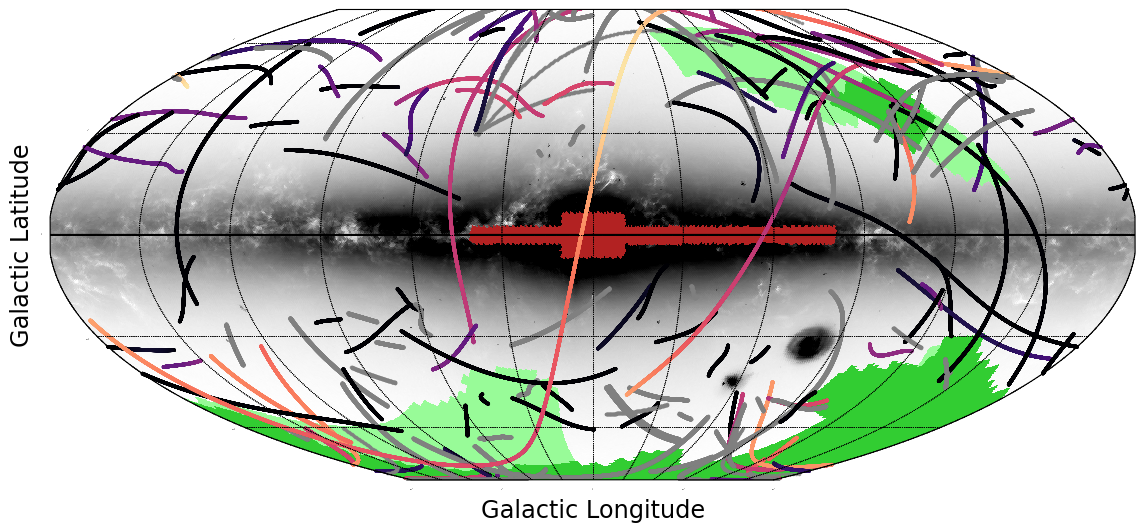

In [14]:
fig = plt.figure(1, figsize=(14, 11))
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax, extent=[-180,180, -90, 90], galactic=True, min_lon_ticklabel_delta=0.06)

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0)

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(-180,180), lat_range=(-90, 90), alpha=alph, vmin=1, vmax=3, cmap=cm)

sp.draw_milky_way(width=0,zorder=1)
patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')
# patch_GPS = mpatches.Patch(color=col_dict[3], label='GPS')

# Add circles for the other surveys -- the size of the circles are kind of proportional to their footprints but it's not the actual size
#GBTDS
# sp.circle(gbtds_one.galactic.l.value, gbtds_one.galactic.b.value, 2.5/2, label='GBTDS', fill=True, alpha=alph, color='gold')
# #HLTDS
# sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
# sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
# sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)
# #HLWAS DEEP
# sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
# sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)


#plot stream tracks

cbh = plot_streams(sp, mws, dist=True)


#make legend
# handles, labels = sp.ax.get_legend_handles_labels()
# #handles.extend([patch_HLWAS_w, patch_HLWAS_m, patch_GPS])
# shandles = handles[0:5]
# shandles.extend([patch_HLWAS_m,patch_HLWAS_w])
# shandles.extend([patch_GPS])
#shandles.extend(handles[5:])


# box = ax.get_position()
# ax.set_position([box.x0, box.y0 + box.height * 0.1,
#                  box.width, box.height * 0.9])

# sp.legend(handles=shandles, loc='lower center', ncol=4, bbox_to_anchor=(0, -0.35, 1.0, 0.55), fontsize=12)

sp.ax.tick_params(axis="x", labelsize=0)
sp.ax.tick_params(axis="y", labelsize=0)
# cb=plt.colorbar(cbh,shrink=0.5)
# cb.ax.tick_params(labelsize=18)
# cb.ax.set_ylabel('Distance (kpc)', fontsize=18)
# cb.ax.set_yticks([5,10,20,40,60])
# cb.ax.set_yticklabels([5,10,20,40,60])
#plt.savefig('../figures/ccs_footprints_streams.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/hlwas_footprint_streams_nolabels.png',dpi=300,bbox_inches='tight')
plt.show()

## additional setup for polar projections (drop the regions in the galactic plane)

In [15]:
maps = [HLWAS_wide, HLWAS_medium]
combined_map = np.zeros_like(HLWAS_wide)
for i, m in enumerate(maps):
    m[m==hp.UNSEEN] = 0.
    combined_map[m!=0] = (i+1)*1.0
combined_map[combined_map <=0] = hp.UNSEEN # Fill back with UNSEEN
combined_map = change_coord(combined_map,['C','G'])

col_dict = {1: "palegreen", # "lightskyblue",
            2: "limegreen"}

# We create a colorbar from our list of colors
cm = ListedColormap([col_dict[x] for x in col_dict.keys()])

# Let's also define the description of each category : 1 (blue) is Sea; 2 (red) is burnt, etc... Order should be respected here ! Or using another dict maybe could help.
labels = np.array(["HLWAS WIDE", "HLWAS MEDIUM"])
len_lab = len(labels)

In [16]:
ns = hp.get_nside(combined_map)

combined_map[hp.ang2pix(ns,euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value,lonlat=True)]

np.float64(2.0)

## plot north and south pole projections

### southern galactic cap with streams

In [17]:
id_in_hlwas = [99,60,90,96,95,93,8,78,90,36,72,3,64,108,29,125,54,79,4,26,24,110,126,137,30,67,68,125,25,118,67,66,69,122,29]
in_hlwas = []
for st in mws.keys():
    if mws[st].ID in id_in_hlwas:
        in_hlwas.append(st)

In [18]:
#select streams that cross the southern galactic cap
s_pole = mws.get_track_names_in_sky_window([0,359]*u.deg, [-90,-30]*u.deg, frame=astropy.coordinates.Galactic)


In [29]:
# select galaxies in there too
nbg, nbg_coords = read_galaxies()
nbgs_in_hlwas_north,nbgs_in_hlwas_south = select_galaxies_in_footprint(combined_map, nbg_coords, nbg)

10 galaxies in northern footprint
15 galaxies in southern footprint


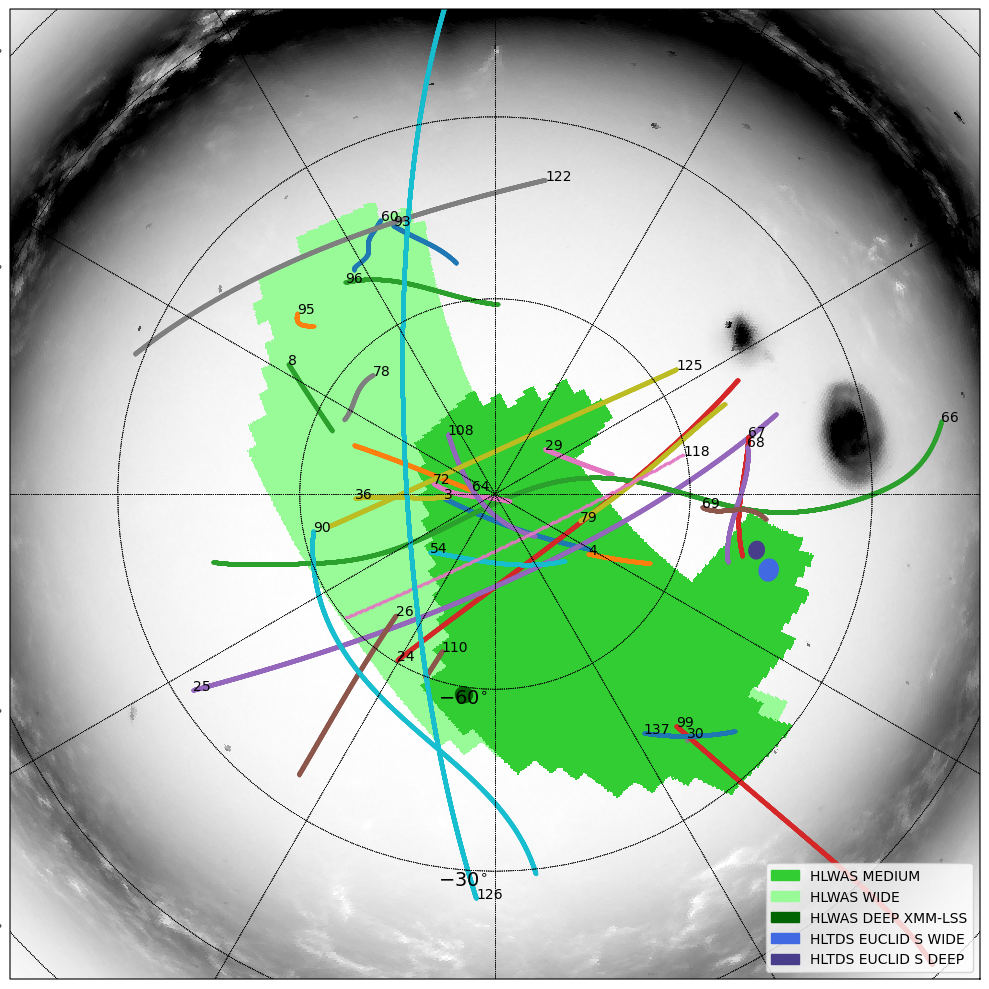

In [19]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=-90.0, galactic=True, extent=[0,360, -90,-10])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(-90, -10))
im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(-90, -10), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
#sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
#sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')

plot_streams(sp,mws,dist=False, streamlist = in_hlwas, annotate=True)

#cbh = plot_galaxies(sp, gals=nbg)

shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles[:3])

sp.legend(handles=shandles, loc='lower right', ncol=1,  fontsize=10)#, bbox_to_anchor=(1.0,0.0, 0.05, 1.0))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
#plt.colorbar(cbh,label='Distance (kpc)', shrink=0.5)
#plt.savefig('../figures/ccs_footprints_streams_southpole.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_streams_southpole.png',dpi=200,bbox_inches='tight')
#plt.show()

Streams colored by distance

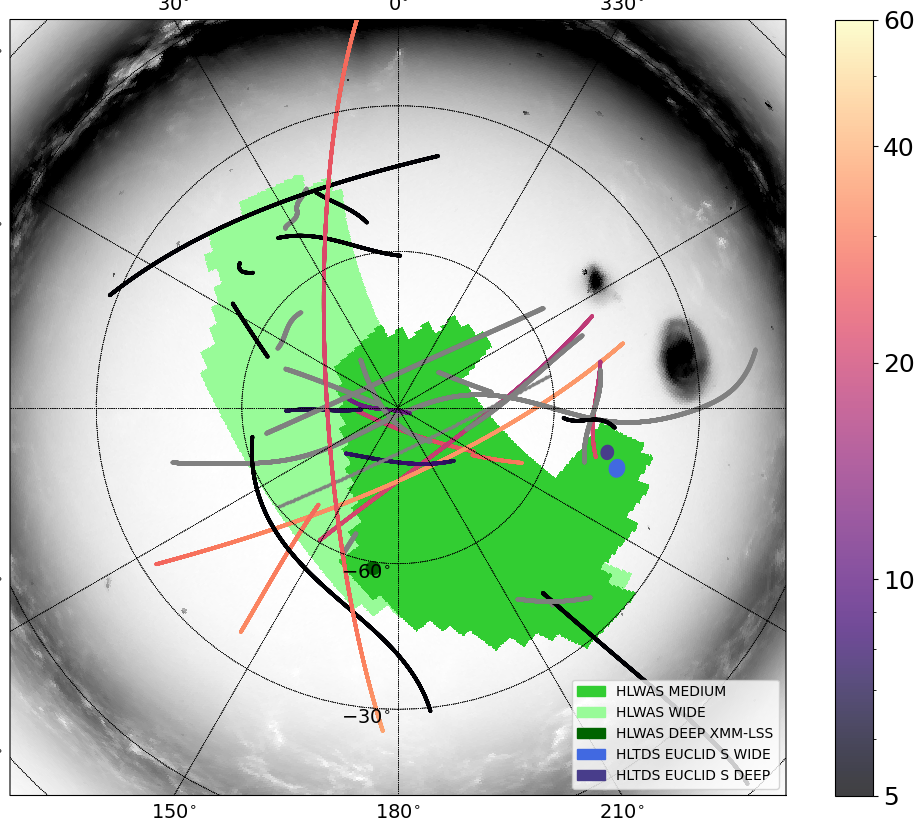

In [20]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=-90.0, galactic=True, extent=[0,360, -90,-10])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(-90, -10))
im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(-90, -10), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
#sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
#sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')

cbh=plot_streams(sp,mws,dist=True, streamlist = in_hlwas, annotate=False)
#nbg, nbg_coords = read_galaxies()
#cbh = plot_galaxies(sp, gals=nbg)

shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles[:3])

sp.legend(handles=shandles, loc='lower right', ncol=1,  fontsize=10)#, bbox_to_anchor=(1.0,0.0, 0.05, 1.0))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
cb = plt.colorbar(cbh,shrink=0.8)
cb.ax.tick_params(labelsize=18)
cb.ax.set_yticks([5,10,20,40,60])
cb.ax.set_yticklabels([5,10,20,40,60])
#cb.ax.set_ylabel('Distance (kpc)',fontsize=18,labelpad=0)
#plt.savefig('../figures/ccs_footprints_streams_southpole.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_streams_southpole_distances.png',dpi=300)
plt.show()

Streams with galaxies superimposed

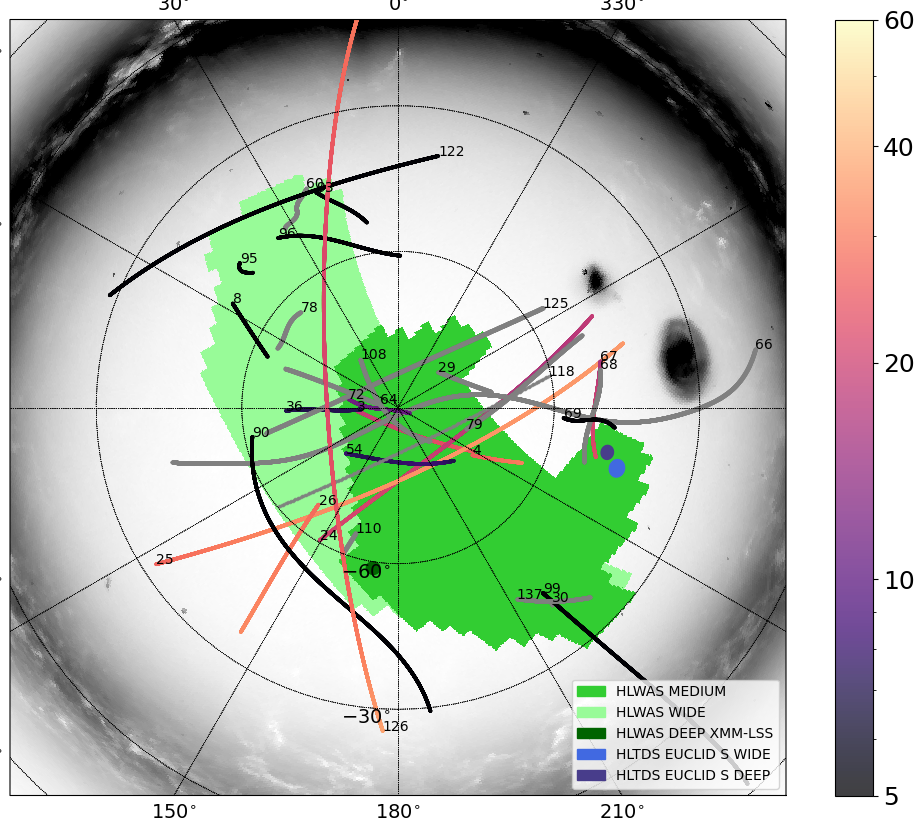

In [30]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=-90.0, galactic=True, extent=[0,360, -90,-10])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(-90, -10))
im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(-90, -10), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
#sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
#sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')

#plot_galaxies(sp,glist=nbgs_in_hlwas_south[5:13],annotate=False)
cbh=plot_streams(sp,mws,dist=True, streamlist = in_hlwas, annotate=True)


shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles[:3])

sp.legend(handles=shandles, loc='lower right', ncol=1,  fontsize=10)#, bbox_to_anchor=(1.0,0.0, 0.05, 1.0))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
cb = plt.colorbar(cbh,shrink=0.8)
cb.ax.tick_params(labelsize=18)
cb.ax.set_yticks([5,10,20,40,60])
cb.ax.set_yticklabels([5,10,20,40,60])
#cb.ax.set_ylabel('Distance (kpc)',fontsize=18,labelpad=0)
#plt.savefig('../figures/ccs_footprints_streams_southpole.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_streams_southpole_distances_with_galaxies.png',dpi=300)
plt.show()

In [31]:
for st in in_hlwas:
    if not mws.summary.has_D[st]:
        if not mws.summary.has_pm[st]:
            print(mws[st].ID, " & ", mws[st].stream_name, " & & & \\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")
        else:
            print(mws[st].ID, " & ", mws[st].stream_name, " &    & *  & \\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")
            
    if mws.summary.has_D[st]:
        if not mws.summary.has_pm[st]:
            print(mws[st].ID, " & ", mws[st].stream_name, " &  *  &  &\\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")
        else:
            print(mws[st].ID, " & ", mws[st].stream_name, " &  *  & * & \\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")

3  &  AAU-ATLAS  &  *  & * & \citet{Li2021} \\
4  &  AAU-AliqaUma  &  *  & * & \citet{Li2021} \\
8  &  Aquarius  &  *  & * & \citet{Williams2011} \\
24  &  Cetus-New  &  *  & * & \citet{Yuan2021} \\
25  &  Cetus-Palca  &  *  & * & \citet{Thomas2021} \\
26  &  Cetus  &  *  &  &\citet{Yam2013} \\
29  &  Elqui  &    & *  & \citet{Shipp2019,Shipp2018} \\
30  &  Eridanus  & & & \citet{Myeong2017,Harris1996} \\
36  &  Gaia-2  &  *  & * & \citet{Ibata2021} \\
54  &  Kwando  &  *  & * & \citet{Ibata2021} \\
60  &  M30  & & & \citet{Sollima2020,Harris1996} \\
64  &  Molonglo  & & & \citet{Grillmair2017_south} \\
66  &  Murrumbidgee  & & & \citet{Grillmair2017_south} \\
67  &  NGC1261  &  *  & * & \citet{Ibata2021} \\
68  &  NGC1261a  &    & *  & \citet{Ibata2024} \\
69  &  NGC1261b  &  *  & * & \citet{Ibata2024} \\
72  &  NGC288  &  *  & * & \citet{Ibata2021} \\
78  &  NGC7492  &    & *  & \citet{Ibata2024} \\
79  &  New-1  &    & *  & \citet{Ibata2024} \\
90  &  New-2  &  *  & * & \citet{Ibata

### northern galactic cap with streams

In [32]:
ids_in_north = [99,31,55,9,101,28,140,127,113,111,128,141,109,38,133,84,37,41,32,42,119,27,62,42,83,80,50,43]
set(ids_in_north).intersection(set(id_in_hlwas))

{99}

In [33]:
in_hlwas_north = []
for st in mws.keys():
    if mws[st].ID in ids_in_north:
        in_hlwas_north.append(st)

In [34]:
#select streams that cross the northern hlwas fields
n_pole = mws.get_track_names_in_sky_window([220,330]*u.deg, [15,60]*u.deg, frame=astropy.coordinates.Galactic)

In [35]:
#select the stream that goes across the elais field
elais = mws.get_track_names_in_sky_window([(elais_n1.galactic.l.value - 2.), (elais_n1.galactic.l.value+2.)]*u.deg, 
                                          [elais_n1.galactic.b.value - 2., elais_n1.galactic.b.value + 2.]*u.deg,
                                          frame=astropy.coordinates.Galactic)

In [36]:
#select the stream that goes across the northern deep field
cosmos = mws.get_track_names_in_sky_window([(hlwas_cosmos.galactic.l.value - 2.), (hlwas_cosmos.galactic.l.value+2.)]*u.deg, 
                                          [hlwas_cosmos.galactic.b.value - 2., hlwas_cosmos.galactic.b.value + 2.]*u.deg,
                                          frame=astropy.coordinates.Galactic)

all streams annotated with numbers

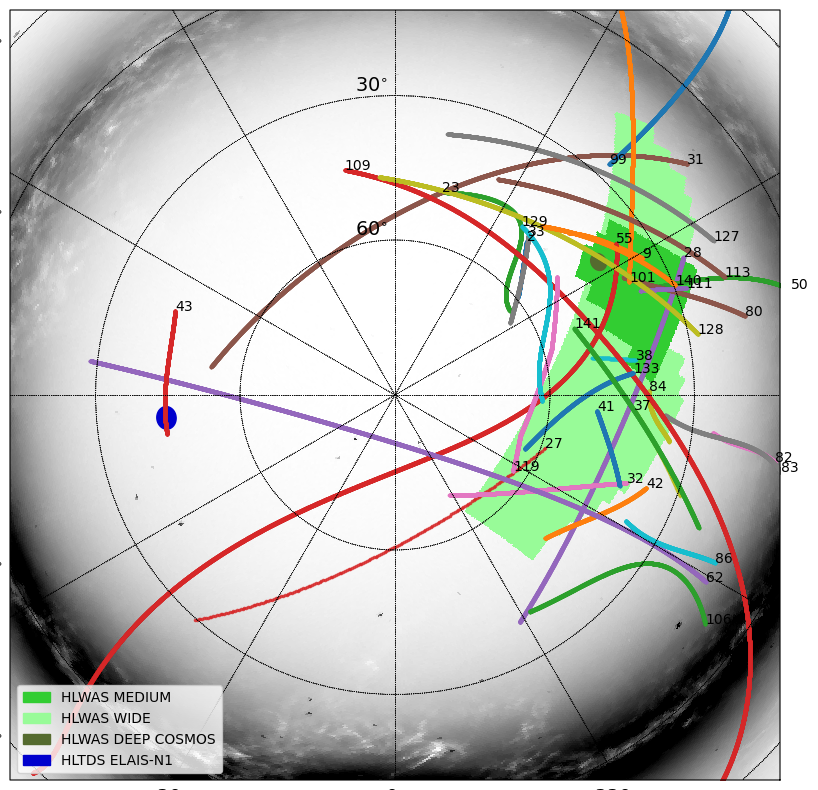

In [37]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=90.0, galactic=True, extent=[0,360, 10,90])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(10,90))

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(10,90), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
#sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
#sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
#sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

#plot_streams(sp,mws,dist=False,streamlist=in_hlwas_north, annotate=True)
plot_streams(sp,mws,dist=False,streamlist=n_pole, annotate=True)
plot_streams(sp,mws,dist=False,streamlist=elais, annotate=True)

patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')
shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles[:2])


sp.legend(handles=shandles, loc='lower left', ncol=1,  fontsize=10)#, bbox_to_anchor=(1.0,0.05, 0.05, 1.0))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
#plt.savefig('../figures/ccs_footprints_streams_northpole.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_streams_northpole_all.png',dpi=200,bbox_inches='tight')
plt.show()

Colored by distance instead of annotated

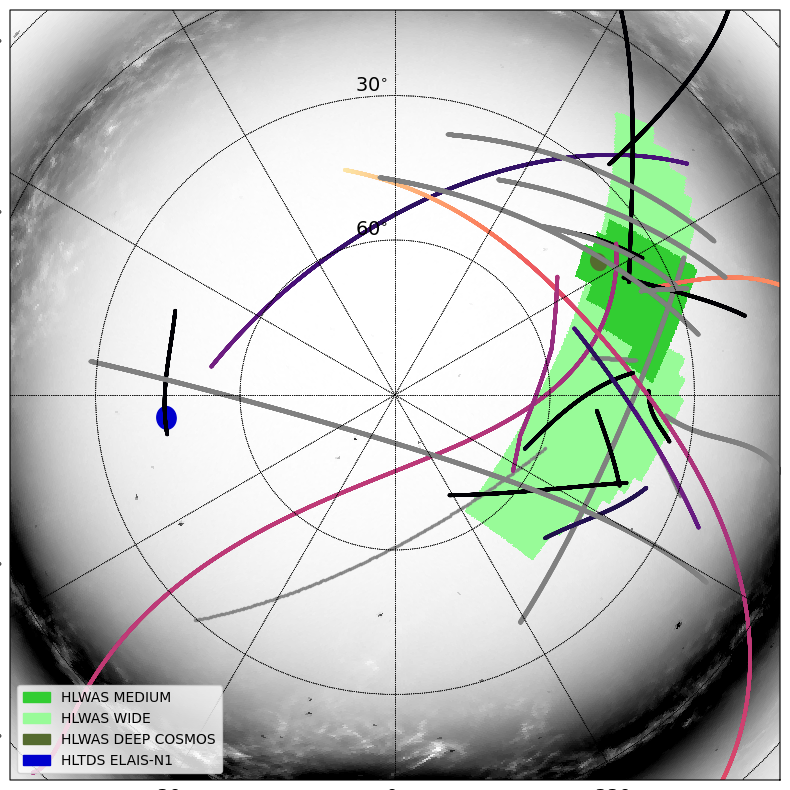

In [38]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=90.0, galactic=True, extent=[0,360, 10,90])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(10,90))

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(10,90), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
#sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
#sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
#sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

cbh=plot_streams(sp,mws,dist=True, streamlist = in_hlwas_north, annotate=False)

patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')
shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles[:2])


sp.legend(handles=shandles, loc='lower left', ncol=1,  fontsize=10)#, bbox_to_anchor=(1.0,0.05, 0.05, 1.0))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)


#plt.savefig('../figures/ccs_footprints_streams_northpole.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_streams_northpole_distances.png',dpi=300)
plt.show()

print out the list formatted as a latex table

In [39]:
for st in in_hlwas_north:
    if not mws.summary.has_D[st]:
        if not mws.summary.has_pm[st]:
            print(mws[st].ID, " & ", mws[st].stream_name, " & & & \\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")
        else:
            print(mws[st].ID, " & ", mws[st].stream_name, " &    & *  & \\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")
            
    if mws.summary.has_D[st]:
        if not mws.summary.has_pm[st]:
            print(mws[st].ID, " & ", mws[st].stream_name, " &  *  &  &\\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")
        else:
            print(mws[st].ID, " & ", mws[st].stream_name, " &  *  & * & \\citet{" + mws.summary.TrackRefsLatex[st]+ "} \\\\")

9  &  C-10  &  *  & * & \citet{Ibata2024} \\
27  &  Cocytos  & & & \citet{Grillmair2009} \\
28  &  Corvus  & & & \citet{Mateu2018} \\
31  &  GD-1  &  *  & * & \citet{Ibata2021} \\
32  &  Gaia-1  &  *  & * & \citet{Ibata2021} \\
37  &  Gaia-3  & & & \citet{Malhan2018} \\
38  &  Gaia-4  & & & \citet{Malhan2018} \\
41  &  Gaia-7  &  *  & * & \citet{Ibata2021} \\
42  &  Gaia-8  &  *  & * & \citet{Ibata2021} \\
43  &  Gaia-9  &  *  & * & \citet{Ibata2021} \\
50  &  Jet  &  *  & * & \citet{Ferguson2022} \\
55  &  LMS-1  &  *  & * & \citet{Yuan2020} \\
62  &  M68-Fjorm  &  *  & * & \citet{Palau2019} \\
80  &  New-10  &  *  & * & \citet{Ibata2024} \\
83  &  New-13  &    & *  & \citet{Ibata2024} \\
84  &  New-14  &  *  & * & \citet{Ibata2024} \\
99  &  New-3  &  *  & * & \citet{Ibata2024} \\
101  &  New-5  &  *  & * & \citet{Ibata2024} \\
109  &  Orphan-Chenab  &  *  & * & \citet{Koposov2023} \\
111  &  PS1-B  & & & \citet{Bernard2016} \\
113  &  PS1-D  & & & \citet{Bernard2016} \\
119  &  Para

just the streams that cross the deep fields

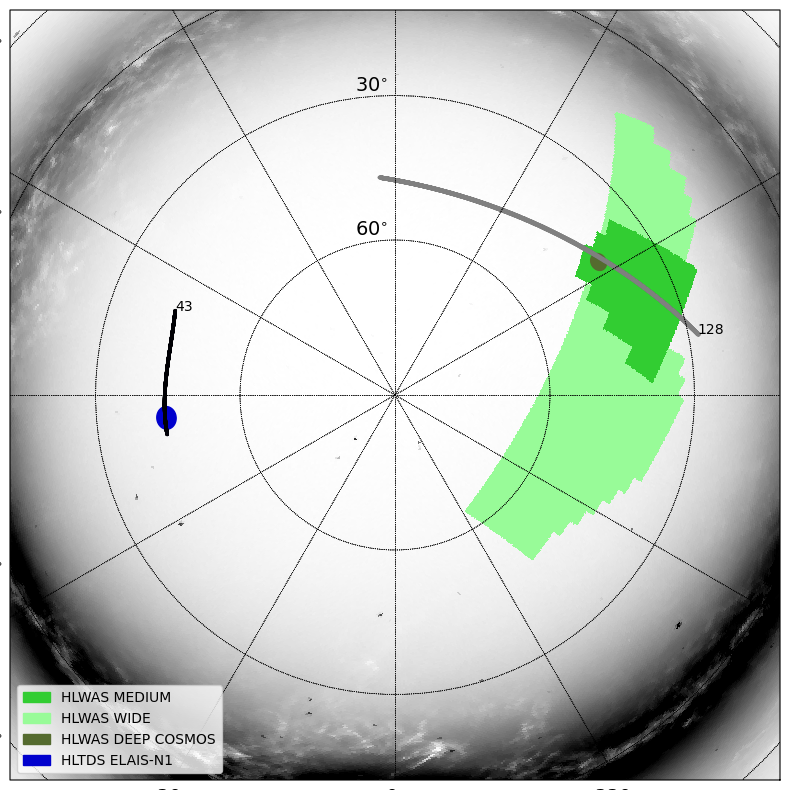

In [40]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=90.0, galactic=True, extent=[0,360, 10,90])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(10,90))

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(10,90), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
#sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
#sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
#sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

#plot_streams(sp,mws,dist=False,streamlist=in_hlwas_north, annotate=True)
cbh=plot_streams(sp,mws,dist=True, streamlist = elais, annotate=True)
cbh=plot_streams(sp,mws,dist=True, streamlist = cosmos, annotate=True)

patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')
shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles[:2])


sp.legend(handles=shandles, loc='lower left', ncol=1,  fontsize=10)#, bbox_to_anchor=(1.0,0.05, 0.05, 1.0))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)


#plt.savefig('../figures/ccs_footprints_streams_northpole.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/deep_streams_northpole_distances.png',dpi=300)
plt.show()

# legacy code

### southern galactic cap with nearby galaxies

In [ ]:
nbgs, nbg_coords = read_galaxies()

In [ ]:
in_mw = nbgs['D (Mpc)']<0.3
in_lg = (~in_mw) * (nbgs['D (Mpc)']<1.0)
in_lv = (~in_mw) * (~in_lg)

In [4]:

nbglm=pd.read_csv(DATA_DIR / 'Roman_MW_Dwarf_Targets.csv')

In [ ]:
nbglm

In [ ]:
len(nbglm)

In [ ]:
nbgs_in_hlwas_north=[]
nbgs_in_hlwas_south=[]
for i,sat in enumerate(nbg_coords):
    ipix = hp.ang2pix(hp.get_nside(combined_map),sat.galactic.l.value, sat.galactic.b.value,lonlat=True)
    if not combined_map[ipix]==hp.UNSEEN:
        if sat.galactic.b.value > 0:
            nbgs_in_hlwas_north.append(i)
        else:
            nbgs_in_hlwas_south.append(i)
nbglm_in_hlwas_north=[]
nbglm_in_hlwas_south=[]
for i in range(len(nbglm)):
    coord = astropy.coordinates.SkyCoord(nbglm['ra'][i]*u.deg,nbglm['dec'][i]*u.deg)
    ipix = hp.ang2pix(hp.get_nside(combined_map),coord.galactic.l.value, coord.galactic.b.value,lonlat=True)
    if coord.galactic.b.value > 0:
        nbglm_in_hlwas_north.append(i)
    else:
        nbglm_in_hlwas_south.append(i)

    

In [ ]:
nbglm['name'][nbglm_in_hlwas_north]

In [ ]:
nbgs['Gal. Name    '][nbgs_in_hlwas_north][~in_mw]

In [ ]:
nbglm['name'][nbglm_in_hlwas_south]

In [ ]:
nbgs['Gal. Name    '][nbgs_in_hlwas_south][~in_mw]

In [ ]:
np.isclose?

In [ ]:
nbgs_in_hlwas_north_nomw = nbgs_in_hlwas_north.copy()
ralist = nbg_coords[nbgs_in_hlwas_north].ra.to(u.deg).value
declist = nbg_coords[nbgs_in_hlwas_north].dec.to(u.deg).value

for i in nbglm_in_hlwas_north:
    ra = nbglm['ra'][i]
    dec = nbglm['dec'][i]
    xmatch = np.isclose(ralist,ra,atol=1e-3) * np.isclose(declist, dec,atol=1e-3)
    if np.any(xmatch):
        nbgs_in_hlwas_north_nomw.remove(np.array(nbgs_in_hlwas_north)[xmatch])
        


In [ ]:
nbgs['Gal. Name    '][in_mw]

In [ ]:
nbgs['Gal. Name    '][nbgs_in_hlwas_south]

In [ ]:
nbgs_in_hlwas_south_nomw = nbgs_in_hlwas_south.copy()
ralist = nbg_coords[nbgs_in_hlwas_south].ra.to(u.deg).value
declist = nbg_coords[nbgs_in_hlwas_south].dec.to(u.deg).value

for i in nbglm_in_hlwas_south:
    ra = nbglm['ra'][i]
    dec = nbglm['dec'][i]
    xmatch = np.isclose(ralist,ra,atol=1e-2) * np.isclose(declist, dec,atol=1e-2)
    if np.any(xmatch):
        nbgs_in_hlwas_south_nomw.remove(np.array(nbgs_in_hlwas_south)[xmatch])
        


In [ ]:
plt.plot(nbg_coords[nbgs_in_hlwas_south].ra,nbg_coords[nbgs_in_hlwas_south].dec,'*')
plt.plot(nbglm['ra'][nbglm_in_hlwas_south],nbglm['dec'][nbglm_in_hlwas_south],'o',mfc='none')
plt.plot(nbg_coords[56].ra,nbg_coords[56].dec,'^')

In [ ]:
plt.plot(nbg_coords[nbgs_in_hlwas_north].ra,nbg_coords[nbgs_in_hlwas_north].dec,'*')
plt.plot(nbglm['ra'][nbglm_in_hlwas_north],nbglm['dec'][nbglm_in_hlwas_north],'o',mfc='none')
plt.plot(nbg_coords[60].ra,nbg_coords[60].dec,'^')

In [ ]:
plt.plot(

In [ ]:
inorth = np.arange(1, len(nbgs_in_hlwas_north)+1).astype(str)
inorth

isouth = (np.arange(1,len(nbgs_in_hlwas_south)+1) + len(nbgs_in_hlwas_north)).astype(str)
inorth, isouth

In [ ]:
fig, ax = plt.subplots(figsize=(11,9))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=-90.0, galactic=True, extent=[0,360, -90,-10])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(-90, -10))
im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(-90, -10), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
#sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
#sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
#sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
#sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
#sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')


#plot_streams(sp,mws,dist=False, streamlist = s_pole, annotate=True)
cbh = plot_galaxies(sp, glist=nbgs_in_hlwas_south,annotate=True,glabels=nbgs['Gal. Name    '][nbgs_in_hlwas_south])


# sp.draw_polygon([nbg_coords[nbgs_in_hlwas_south[2]].galactic.l.value,1.02*nbg_coords[nbgs_in_hlwas_south[2]].galactic.l.value],
#             [nbg_coords[nbgs_in_hlwas_south[2]].galactic.b.value,1.02*nbg_coords[nbgs_in_hlwas_south[2]].galactic.b.value],
#             edgecolor='k',facecolor=None,lw=2)
shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles)

sp.legend(handles=shandles, loc='upper left', ncol=2,  fontsize=10, bbox_to_anchor=(0.0,0.0, 1.0, 0.05))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
cb=plt.colorbar(cbh, shrink=0.5)
cb.set_label(label='Distance (Mpc)', size=16)
cb.ax.tick_params(labelsize=16)
plt.tight_layout(h_pad=0.1,w_pad=0.1)
#plt.savefig('../figures/ccs_footprints_nbgs_southpole.pdf',dpi=600,bbox_inches='tight')
plt.savefig('../figures/ccs_footprints_nbgs_southpole.png',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
for i,sat in enumerate(nbg_coords):
    ipix = hp.ang2pix(hp.get_nside(combined_map),sat.galactic.l.value, sat.galactic.b.value,lonlat=True)
    if not combined_map[ipix]==hp.UNSEEN:
        nbgs_in_hlwas.append(i)
        which_s = labels[int(combined_map[ipix])-1][6:].lower()
        if sat.galactic.b.value > 0: 
            which_s += ' N'
        else:
            which_s += ' S'
        print(nbgs['Gal. Name    '][i], '&', nbgs['RA J2000  '][i],'&', nbgs['DEC J2000'][i] ,'&', nbgs['AbsBmag '][i],'&', nbgs[' D (Mpc)'][i] ,'&', nbgs[' Kmag '][i],'&', which_s, ' \\\\' )

In [ ]:
nbgs_in_hlwas

In [ ]:
for i,sat in enumerate(nbg_coords[in_mw]):
    ipix = hp.ang2pix(hp.get_nside(combined_map),sat.galactic.l.value, sat.galactic.b.value,lonlat=True)
    if not combined_map[ipix]==hp.UNSEEN: print(nbgs[in_mw]['Gal. Name    '][i], combined_map[ipix])

In [ ]:
combined_map[i3]

### southern galactic cap with GCs

In [ ]:
gcs=read_gcs(vb=True)

In [ ]:
near_hlwas_north_names = ['Pal 12','NGC 7099','NGC 7492','NGC 288', 'Whiting 1','Eridanus', 'E 1', 'Pal 13','NGC 1261','NGC 1904','NGC 1851','NGC 7089']

In [ ]:
near_hlwas_north = np.array([np.where(gcs['Name']==n)[0][0] for n in in_hlwas_north_names])

In [ ]:
gcs[near_hlwas_north]

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=-90.0, galactic=True, extent=[0,360, -90,-10])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(-90, -10))
im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(-90, -10), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
#sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
#sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)

cbh=plot_gcs(sp,gcs, near_hlwas_north,annotate=True)


patch_HLWAS_w = mpatches.Patch(color=col_dict[1], label='HLWAS WIDE')
patch_HLWAS_m = mpatches.Patch(color=col_dict[2], label='HLWAS MEDIUM')


shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles[:3])

sp.legend(handles=shandles, loc='lower right', ncol=1,  fontsize=10)#, bbox_to_anchor=(1.0,0.0, 0.05, 1.0))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
plt.colorbar(cbh,label='Distance (kpc)', shrink=0.5)
plt.savefig('../figures/ccs_footprints_gcs_southpole.png',dpi=200,bbox_inches='tight')
plt.show()

### northern galactic cap with nearby galaxies

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sp = skyproj.LaeaSkyproj(ax=ax, lat_0=90.0, galactic=True, extent=[0,360, 10,90])

alph = 1.0

sp.draw_hpxmap(scaled_gmap,cmap='gray_r',vmin=0.5,vmax=5.0,lon_range=(0,360), lat_range=(10,90))

im, _, _, _ = sp.draw_hpxmap(combined_map, lon_range=(0,360), lat_range=(10,90), alpha=alph, vmin=1, vmax=3, cmap=cm, zoom=False)
#sp.circle(hlwas_cosmos.galactic.l.value, hlwas_cosmos.galactic.b.value, 3.1/2, label='HLWAS DEEP COSMOS', alpha=alph, fill=True, color='darkolivegreen')
#sp.circle(hlwas_xmm.galactic.l.value, hlwas_xmm.galactic.b.value, 2.5/2, label='HLWAS DEEP XMM-LSS', alpha=alph, color='darkgreen', fill=True)
#sp.circle(elais_n1.galactic.l.value, elais_n1.galactic.b.value, 4./2, label='HLTDS ELAIS-N1', fill=True, alpha=alph, color='mediumblue')
#sp.circle(euclid_s_wide.galactic.l.value, euclid_s_wide.galactic.b.value, 3.1/2, label='HLTDS EUCLID S WIDE', alpha=alph, fill=True, color='royalblue')
#sp.circle(euclid_s_deep.galactic.l.value, euclid_s_deep.galactic.b.value, 2.5/2, label='HLTDS EUCLID S DEEP', alpha=alph, color='darkslateblue', fill=True)


#plot_streams(sp,mws,dist=False, streamlist = s_pole, annotate=True)
cbh = plot_galaxies(sp, glist=nbgs_in_hlwas_north,annotate=True,glabels=nbgs['Gal. Name    '][nbgs_in_hlwas_north])


shandles=[patch_HLWAS_m,patch_HLWAS_w]
handles, labels = sp.ax.get_legend_handles_labels()
shandles.extend(handles)

sp.legend(handles=shandles, loc='upper left', ncol=2,  fontsize=10, bbox_to_anchor=(0.0,0.0, 1.0, 0.05))

sp.ax.tick_params(axis="x", labelsize=14)
sp.ax.tick_params(axis="y", labelsize=14)
#cb=plt.colorbar(cbh, shrink=0.5)
#cb.set_label(label='Distance (Mpc)', size=16)
#cb.ax.tick_params(labelsize=16)
plt.tight_layout(h_pad=0.1,w_pad=0.1)
plt.savefig('../figures/ccs_footprints_nbgs_northpole.png',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
astropy.coordinates.Galactocentric()

In [ ]:
astropy.coordinates.SkyCoord?

In [ ]:
cloud1=astropy.coordinates.SkyCoord(l=165*u.deg,b=-32*u.deg, distance=40*u.pc, frame=astropy.coordinates.Galactic)
cloud2=astropy.coordinates.SkyCoord(l=27*u.deg,b=-31*u.deg, distance=45*u.pc, frame=astropy.coordinates.Galactic)
cloud3=astropy.coordinates.SkyCoord(l=329*u.deg,b=46*u.deg, distance=65*u.pc, frame=astropy.coordinates.Galactic)

In [ ]:
cloud1.galactocentric.z

In [ ]:
plt.plot(cloud1.galactocentric.x, cloud1.galactocentric.y,'*')
plt.plot(cloud2.galactocentric.x, cloud2.galactocentric.y,'*')
plt.plot(cloud3.galactocentric.x, cloud3.galactocentric.y,'*')
plt.plot(-8.122e3,0,'oy')
xb=-8.1e3
yb=0
plt.plot(55*np.cos(np.linspace(0,2*np.pi,100))+xb,55*np.sin(np.linspace(0,2*np.pi,100))+yb,'--k')
plt.gca().set_aspect('equal')

In [ ]:
plt.plot(cloud1.galactocentric.x, cloud1.galactocentric.y,'.')